# K-means clustering (another dataset)

As you might have noticed, there is another dataset in the data directory called `ML-ratings.csv`. This data comes from MovieLens and is a small subset of the data used in our manual. 

Can you cluster this data using the same methods as seen before (notebook 3)?  Is the clustering better than our books dataset or not?

In [1]:
import pandas as pd
df_ml_ratings = pd.read_csv('data/ML-ratings.csv', sep=',')
df_ml_ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [ ]:
# code goes here
# Re-load necessary libraries after execution state reset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.sparse import csr_matrix
from sklearn.decomposition import PCA


# Recreate movie rating matrix
movie_rating_matrix = df_ml_ratings.pivot_table(index='movieId', columns='userId', values='rating', fill_value=0)

# Convert to sparse matrix to optimize memory usage
sparse_movie_matrix = csr_matrix(movie_rating_matrix)

pca = PCA(n_components=10)  
movie_pca = pca.fit_transform(sparse_movie_matrix.toarray())

kmeans_movies = KMeans(n_clusters=5, random_state=42, n_init=10)
movie_clusters = kmeans_movies.fit_predict(movie_pca)

df_movie_clusters = pd.DataFrame({'movieId': movie_rating_matrix.index, 'cluster': movie_clusters})

movie_cluster_counts = df_movie_clusters['cluster'].value_counts()
movie_cluster_counts



cluster
0    8296
3     759
4     467
1     149
2      53
Name: count, dtype: int64

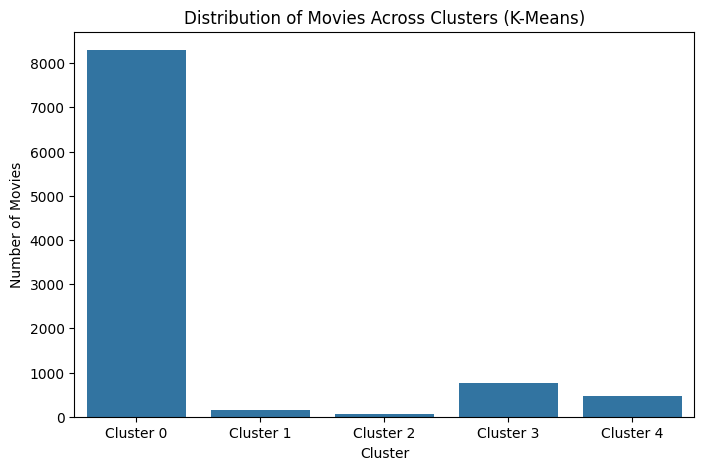

cluster
0    8296
3     759
4     467
1     149
2      53
Name: count, dtype: int64

In [6]:
# Plot the distribution of movies across clusters
plt.figure(figsize=(8, 5))
sns.barplot(x=movie_cluster_counts.index, y=movie_cluster_counts.values)
plt.xlabel("Cluster")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movies Across Clusters (K-Means)")
plt.xticks(ticks=range(5), labels=[f"Cluster {i}" for i in range(5)])
plt.show()

# Display the cluster counts numerically
movie_cluster_counts
